In [10]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
print(f"Current working directory: {repo_root}")
import SysSimX

sys.path.insert(0, str(repo_root/'demos/ControlledPendulum/MyModels'))
from OpenSim.opensim_pendulum import OpenSimPendulum

sys.path.insert(0, str(repo_root/'demos/ControlledPendulum/'))
from FEM.fem_pendulum import FEMPendulum

Current working directory: /home/flo/repos/SystemSimulation


In [2]:
MASTER = FEMPendulum(name='MASTER')
MASTER.initialize(0.0)
MASS = MASTER.mass
INERTIA = MASTER.inertia

corresponding_length = np.sqrt(INERTIA / MASS)

In [3]:
model = OpenSimPendulum()
model._use_gravity = True
model._with_contact = True

model.parameters['Model']['mass'] = MASS
model.parameters['Model']['length'] = corresponding_length

model.parameters['InitialConditions']['q0'] = np.deg2rad(20.0)

In [4]:
# viz = osim.VisualizerUtilities()
# viz.showModel(model.model)

In [5]:
model.parameters['Contact']

{'with_contact': False,
 'stiffness': 1000000.0,
 'dissipation': 0.5,
 'static_friction': 0.9,
 'dynamic_friction': 0.9,
 'viscous_friction': 0.6}

In [6]:
model.parameters['Contact']['stiffness'] = 1e12
model.parameters['Contact']['dissipation'] = 0
model.parameters['Contact']['static_friction'] = 0
model.parameters['Contact']['dynamic_friction'] = 0
model.parameters['Contact']['viscous_friction'] = 0

In [7]:
model.initialize(0.0)
model.set_inputs({'torque': 0.0}, 0)
model.do_step(0, 1)

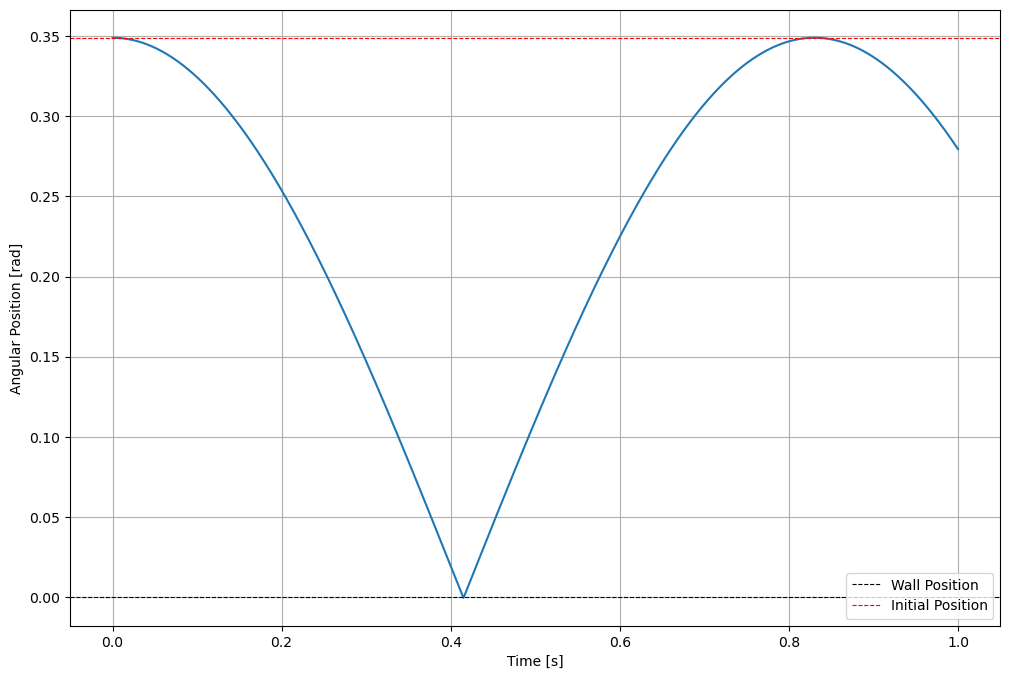

In [8]:
t_vals, q_vals = zip(*model.outputs['q'].history)

plt.figure(figsize=(12, 8))
plt.plot(t_vals, q_vals)
plt.xlabel('Time [s]')
plt.ylabel('Angular Position [rad]')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8, label="Wall Position")
plt.axhline(q_vals[0], color='r', linestyle='--', linewidth=0.8, label='Initial Position')
plt.grid()
plt.legend(loc="lower right")
plt.show()

In [9]:
model.save_model('pendulum_contact.osim')